# OncoScan — Model Training
**Models:** SVM · Random Forest · Logistic Regression
Run all cells top to bottom. Saves 3 `.pkl` model files + `scaler.pkl` to your project root.

In [ ]:
import numpy as np, pandas as pd, pickle, matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, f1_score
print('Imports OK.')

Imports OK.


In [ ]:
data = load_breast_cancer()
X, y = data.data, data.target
print(f'Shape: {X.shape}  |  Benign: {sum(y==1)}  Malignant: {sum(y==0)}')
pd.DataFrame(X, columns=data.feature_names).head()

Shape: (569, 30)  |  Benign: 357  Malignant: 212


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [ ]:
# Split FIRST, then scale — avoids data leakage
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)
print(f'Train: {X_train_sc.shape[0]}  |  Test: {X_test_sc.shape[0]}')

Train: 455  |  Test: 114


In [ ]:
models = {
    'SVM': SVC(
        kernel='rbf', C=10, gamma='scale',
        probability=True, random_state=42
    ),
    'Random Forest': RandomForestClassifier(
        n_estimators=200, max_depth=None,
        min_samples_split=2, random_state=42, n_jobs=-1
    ),
    'Logistic Regression': LogisticRegression(
        C=1.0, max_iter=1000,
        solver='lbfgs', random_state=42
    ),
}
for name, mdl in models.items():
    mdl.fit(X_train_sc, y_train)
    print(f'{name} trained OK.')

SVM trained OK.
Random Forest trained OK.
Logistic Regression trained OK.


In [ ]:
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)
X_full_sc = StandardScaler().fit_transform(X)
print('=' * 60)
for name, mdl in models.items():
    y_pred = mdl.predict(X_test_sc)
    print(f'\n── {name} ──')
    print(classification_report(y_test, y_pred, target_names=['Malignant','Benign']))
    for metric in ['accuracy','f1','recall']:
        s = cross_val_score(mdl, X_full_sc, y, cv=cv, scoring=metric)
        print(f'  CV {metric:<10}: {s.mean():.4f} ± {s.std():.4f}')
print('=' * 60)


── SVM ──
              precision    recall  f1-score   support

   Malignant       0.95      0.98      0.96        42
      Benign       0.99      0.97      0.98        72

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114

  CV accuracy  : 0.9772 ± 0.0176
  CV f1        : 0.9820 ± 0.0138
  CV recall    : 0.9860 ± 0.0187

── Random Forest ──
              precision    recall  f1-score   support

   Malignant       0.95      0.93      0.94        42
      Benign       0.96      0.97      0.97        72

    accuracy                           0.96       114
   macro avg       0.96      0.95      0.95       114
weighted avg       0.96      0.96      0.96       114

  CV accuracy  : 0.9544 ± 0.0296
  CV f1        : 0.9641 ± 0.0228
  CV recall    : 0.9692 ± 0.0317

── Logistic Regression ──
              precision    recall  f1-score   support

   Malignant       0.98      0.98 

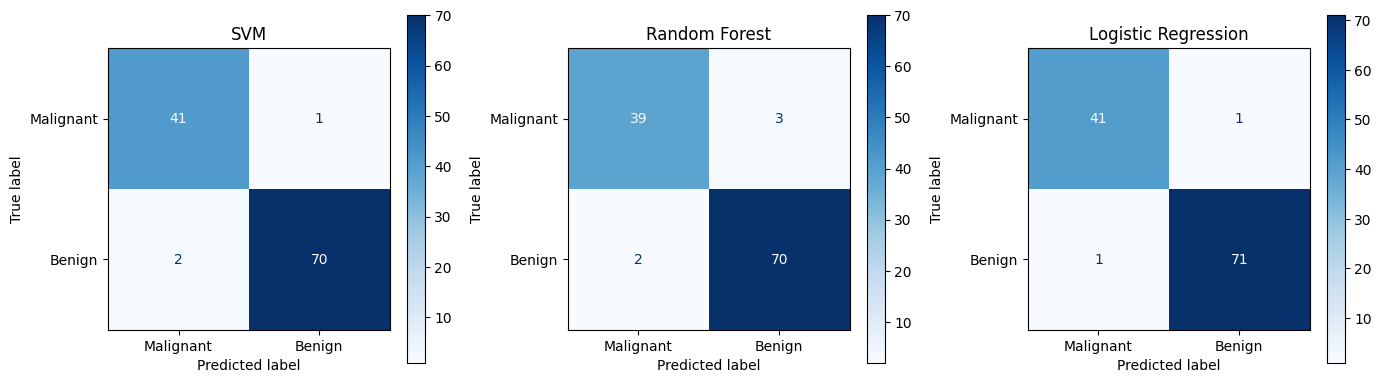

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
for ax, (name, mdl) in zip(axes, models.items()):
    ConfusionMatrixDisplay.from_estimator(
        mdl, X_test_sc, y_test,
        display_labels=['Malignant','Benign'],
        cmap='Blues', ax=ax
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()

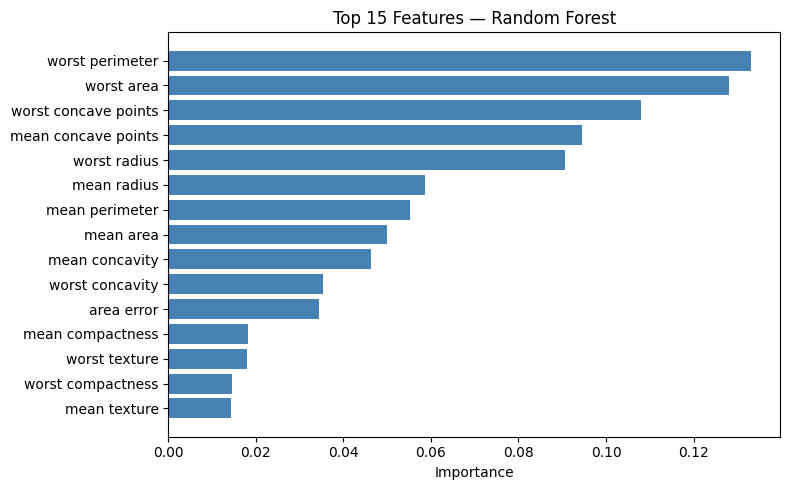

In [ ]:
# Feature importance from Random Forest
rf = models['Random Forest']
idx = np.argsort(rf.feature_importances_)[::-1][:15]
fig, ax = plt.subplots(figsize=(8,5))
ax.barh([data.feature_names[i] for i in idx][::-1], rf.feature_importances_[idx][::-1], color='steelblue')
ax.set_xlabel('Importance')
ax.set_title('Top 15 Features — Random Forest')
plt.tight_layout()
plt.show()

In [ ]:
# Retrain on ALL 569 samples and save
final_scaler = StandardScaler()
X_all = final_scaler.fit_transform(X)

saves = [
    ('svm_model.pkl', SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42)),
    ('model.pkl',     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)),
    ('lr_model.pkl',  LogisticRegression(C=1.0, max_iter=1000, solver='lbfgs', random_state=42)),
]

for path, mdl in saves:
    mdl.fit(X_all, y)
    pickle.dump(mdl, open(path, 'wb'))
    print(f'Saved: {path}')

pickle.dump(final_scaler, open('scaler.pkl', 'wb'))
print('Saved: scaler.pkl')

print(f'\nAll 3 models trained on {X_all.shape[0]} samples. Ready.')

Saved: svm_model.pkl
Saved: model.pkl
Saved: lr_model.pkl
Saved: scaler.pkl

All 3 models trained on 569 samples. Ready.
